# Atelier Préparation de Données Images

## Structure du projet

In [5]:
from pathlib import Path

RAW_DIR = Path("../data/raw")
CLEANED_DIR = Path("../data/cleaned")
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

audit = {}  # dictionnaire qui accumulera les métriques pour reports/audit_images.csv


## Partie 1 – Exploration du dataset

*Développer un programme Python capable de récupérer, pour chaque image, son nom, sa classe, son format, son mode, sa largeur, sa hauteur, l'écart-type de ses pixels, son nombre de canaux et sa taille (NB : prendre en charge aussi les fichiers corrompus).*

In [8]:
import numpy as np
import pandas as pd
from PIL import Image

def explorer_image(chemin_image: Path, classe: str) -> dict:
    """Récupère les métadonnées d'une image. Renvoie un dict même si l'image est corrompue."""
    infos = {
        "nom": chemin_image.name,
        "classe": classe,
        "chemin": str(chemin_image),
        "format": None,
        "mode": None,
        "largeur": None,
        "hauteur": None,
        "ecart_type_pixels": None,
        "nb_canaux": None,
        "taille_octets": chemin_image.stat().st_size,
        "corrompue": False,
    }
    try:
        with Image.open(chemin_image) as img:
            img.verify()

        with Image.open(chemin_image) as img:
            infos["format"] = img.format
            infos["mode"] = img.mode
            infos["largeur"], infos["hauteur"] = img.size

            arr = np.array(img)
            infos["ecart_type_pixels"] = float(arr.std())
            infos["nb_canaux"] = 1 if arr.ndim == 2 else arr.shape[2]

    except Exception:
        infos["corrompue"] = True

    return infos


def explorer_dataset(raw_dir: Path) -> pd.DataFrame:
    lignes = []
    for classe in CLASSES:
        dossier_classe = raw_dir / classe
        if not dossier_classe.exists():
            continue
        for fichier in sorted(dossier_classe.iterdir()):
            if fichier.is_file():
                lignes.append(explorer_image(fichier, classe))
    return pd.DataFrame(lignes)


df = explorer_dataset(RAW_DIR)
audit["total_images"] = len(df)
print(f"Total d\'images explorées : {len(df)}")
df.head()


Total d'images explorées : 1032


,nom,classe,chemin,format,mode,largeur,hauteur,ecart_type_pixels,nb_canaux,taille_octets,corrompue
0,cardboard1.jpg,cardboard,../data/raw/cardboard/cardboard1.jpg,JPEG,RGB,512.0,384.0,40.588529,3.0,17333,False
1,cardboard10.jpg,cardboard,../data/raw/cardboard/cardboard10.jpg,JPEG,RGB,512.0,384.0,42.571288,3.0,21683,False
2,cardboard100.jpg,cardboard,../data/raw/cardboard/cardboard100.jpg,JPEG,RGB,512.0,384.0,46.108305,3.0,14884,False
3,cardboard101.jpg,cardboard,../data/raw/cardboard/cardboard101.jpg,JPEG,RGB,512.0,384.0,72.263996,3.0,14289,False
4,cardboard102.jpg,cardboard,../data/raw/cardboard/cardboard102.jpg,JPEG,RGB,512.0,384.0,48.388937,3.0,18015,False


## Partie 2 – Détecter les images corrompues

*Écrire et se servir d'une fonction qui détecte une image corrompue.*

In [9]:
from PIL import Image

def est_corrompue(chemin_image: Path) -> bool:
    """Renvoie True si l'image ne peut pas être ouverte/vérifiée par PIL."""
    try:
        with Image.open(chemin_image) as img:
            img.verify()
        return False
    except Exception:
        return True


images_corrompues = df[df["corrompue"] == True]
audit["images_corrompues"] = len(images_corrompues)
print(f"Images corrompues : {len(images_corrompues)}")
images_corrompues[["nom", "classe", "chemin"]]


Images corrompues : 6


,nom,classe,chemin
147,cardboard83.jpg,cardboard,../data/raw/cardboard/cardboard83.jpg
326,glass74.jpg,glass,../data/raw/glass/glass74.jpg
446,metal48.jpg,metal,../data/raw/metal/metal48.jpg
633,paper213.jpg,paper,../data/raw/paper/paper213.jpg
791,plastic13.jpg,plastic,../data/raw/plastic/plastic13.jpg
1004,trash3.jpg,trash,../data/raw/trash/trash3.jpg


## Partie 3 – Détecter les images vides
Écrire et se servir d’une fonction qui détecte les images vides : image entièrement noire, image entièrement blanche ou image dont les pixels présentent très peu de variation.

In [10]:
import numpy as np
from PIL import Image

SEUIL_ECART_TYPE = 5.0  # en dessous de ce seuil, l'image est jugée quasi vide

def est_image_vide(chemin_image: Path, seuil: float = SEUIL_ECART_TYPE) -> bool:
    """Détecte une image entièrement noire/blanche ou à très faible variation de pixels."""
    try:
        with Image.open(chemin_image) as img:
            arr = np.array(img.convert("L"))
    except Exception:
        return False  # les corrompues sont déjà traitées en Partie 2

    if arr.std() < seuil:
        return True
    if np.all(arr == 0) or np.all(arr == 255):
        return True
    return False


df_valides = df[df["corrompue"] == False].copy()
df_valides["vide"] = df_valides["chemin"].apply(lambda p: est_image_vide(Path(p)))

images_vides = df_valides[df_valides["vide"] == True]
audit["images_quasi_vides"] = len(images_vides)
print(f"Images quasi vides : {len(images_vides)}")
images_vides[["nom", "classe", "ecart_type_pixels"]]


Images quasi vides : 4


,nom,classe,ecart_type_pixels
167,image-blanche-512x384.jpg,cardboard,1.572536
355,image-noire-512x384.png,glass,110.418239
357,image-blanche-512x384.jpg,metal,1.572536
358,image-noire-512x384.png,metal,110.418239


## Partie 4 – Détecter les différences de résolution
### 1) Déterminer la résolution minimale, la résolution maximale, les résolutions les plus fréquentes et le nombre d'images par résolution.

In [12]:
import pandas as pd

df_valides["resolution"] = list(zip(df_valides["largeur"], df_valides["hauteur"]))

res_min = (df_valides["largeur"].min(), df_valides["hauteur"].min())
res_max = (df_valides["largeur"].max(), df_valides["hauteur"].max())
compte_resolutions = df_valides["resolution"].value_counts()

print(f"Résolution minimale : {res_min}")
print(f"Résolution maximale : {res_max}")
print("\nRésolutions les plus fréquentes :")
print(compte_resolutions.head(10))


Résolution minimale : (np.float64(32.0), np.float64(32.0))
Résolution maximale : (np.float64(512.0), np.float64(384.0))

Résolutions les plus fréquentes :
resolution
(512.0, 384.0)    1013
(32.0, 32.0)         5
(48.0, 32.0)         4
(40.0, 40.0)         4
Name: count, dtype: int64


### 2) On décide qu'une image doit avoir au minimum 64 × 64 pixels. Identifier toutes les images ne respectant pas cette contrainte.

In [13]:
TAILLE_MIN = 64 
images_trop_petites = df_valides[
    (df_valides["largeur"] < TAILLE_MIN) | (df_valides["hauteur"] < TAILLE_MIN)
]
audit["images_trop_petites"] = len(images_trop_petites)
print(f"Images trop petites (< {TAILLE_MIN}x{TAILLE_MIN}) : {len(images_trop_petites)}")
images_trop_petites[["nom", "classe", "largeur", "hauteur"]]


Images trop petites (< 64x64) : 13


,nom,classe,largeur,hauteur
20,cardboard117.jpg,cardboard,48.0,32.0
77,cardboard22.jpg,cardboard,32.0,32.0
133,cardboard70.jpg,cardboard,40.0,40.0
171,glass100.jpg,glass,40.0,40.0
229,glass15.jpg,glass,48.0,32.0
268,glass21.jpg,glass,32.0,32.0
270,glass23.jpg,glass,32.0,32.0
383,metal121.jpg,metal,48.0,32.0
413,metal2.jpg,metal,32.0,32.0
421,metal26.jpg,metal,40.0,40.0


## Partie 5 – Détecter les différents canaux
Déterminer le nombre d'images selon leur nombre de canaux.

Nombre d'images par nombre de canaux :
nb_canaux
1.0       2
3.0    1006
4.0      18
Name: count, dtype: int64


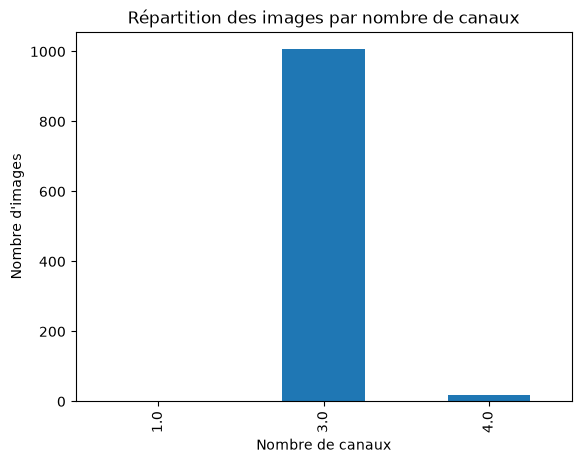

In [14]:
import matplotlib.pyplot as plt

compte_canaux = df_valides["nb_canaux"].value_counts().sort_index()
print("Nombre d\'images par nombre de canaux :")
print(compte_canaux)

audit["images_grayscale"] = int(compte_canaux.get(1, 0))
audit["images_rgba"] = int(compte_canaux.get(4, 0))

compte_canaux.plot(kind="bar", title="Répartition des images par nombre de canaux")
plt.xlabel("Nombre de canaux")
plt.ylabel("Nombre d\'images")
plt.show()


## Partie 6 – Détecter les doublons
Écrire et se servir d’une fonction qui détecte les doublons
NB : Deux fichiers différents peuvent contenir exactement la même image.

In [15]:
import hashlib
from collections import defaultdict
import numpy as np
from PIL import Image
import pandas as pd

def hash_pixels(chemin_image: Path) -> str:
    """Hash MD5 calculé sur les données de pixels (robuste à un changement de format de fichier)."""
    with Image.open(chemin_image) as img:
        arr = np.array(img.convert("RGB"))
    return hashlib.md5(arr.tobytes()).hexdigest()


def detecter_doublons(df_source: pd.DataFrame) -> pd.DataFrame:
    hashes = defaultdict(list)
    for _, row in df_source.iterrows():
        try:
            h = hash_pixels(Path(row["chemin"]))
            hashes[h].append(row["chemin"])
        except Exception:
            continue

    lignes = []
    for h, chemins in hashes.items():
        if len(chemins) > 1:
            for c in chemins:
                lignes.append({"hash": h, "chemin": c})
    return pd.DataFrame(lignes)


df_doublons = detecter_doublons(df_valides)
nb_groupes_doublons = df_doublons["hash"].nunique() if not df_doublons.empty else 0
audit["doublons"] = (len(df_doublons) - nb_groupes_doublons) if not df_doublons.empty else 0
print(f"Groupes de doublons trouvés : {nb_groupes_doublons}")
print(f"Nombre de fichiers en trop (doublons) : {audit['doublons']}")
df_doublons.sort_values("hash") if not df_doublons.empty else df_doublons


Groupes de doublons trouvés : 15
Nombre de fichiers en trop (doublons) : 15


,hash,chemin
27,020356755d7631716228a952bf3c3ead,../data/raw/plastic/plasticx199.jpg
26,020356755d7631716228a952bf3c3ead,../data/raw/plastic/plastic199.jpg
6,03b62f7033ed13e63138ebd048abc4ea,../data/raw/glass/glass176.jpg
7,03b62f7033ed13e63138ebd048abc4ea,../data/raw/plastic/plastic152.jpg
20,116e03527a54192f3693d884d259d23b,../data/raw/paper/paper77.jpg
21,116e03527a54192f3693d884d259d23b,../data/raw/paper/paper77ty.jpg
10,16e737d7e848620a6e96cc7e4f75dd37,../data/raw/metal/metal125.jpg
11,16e737d7e848620a6e96cc7e4f75dd37,../data/raw/metal/metal125po.jpg
2,22a0ea89c32ebdf57e195d9d0b8da9d6,../data/raw/cardboard/image-violet-512x384.gif
3,22a0ea89c32ebdf57e195d9d0b8da9d6,../data/raw/glass/image-violet-512x384.gif


## Partie 7 : Détecter les images mal classées
Effectuer un contrôle visuel pour détecter toute image mal classée.

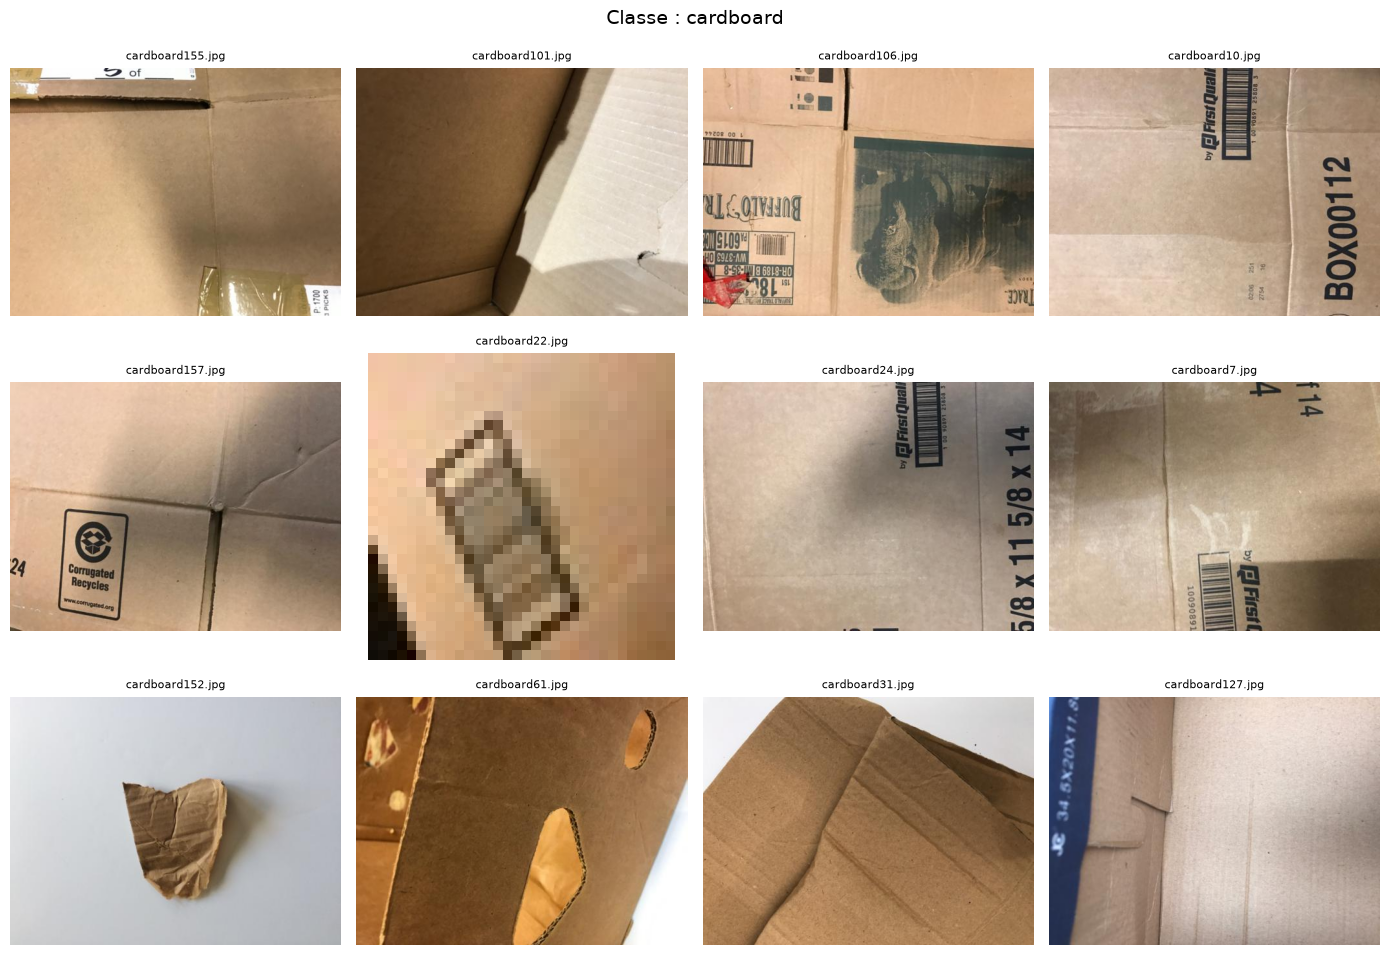

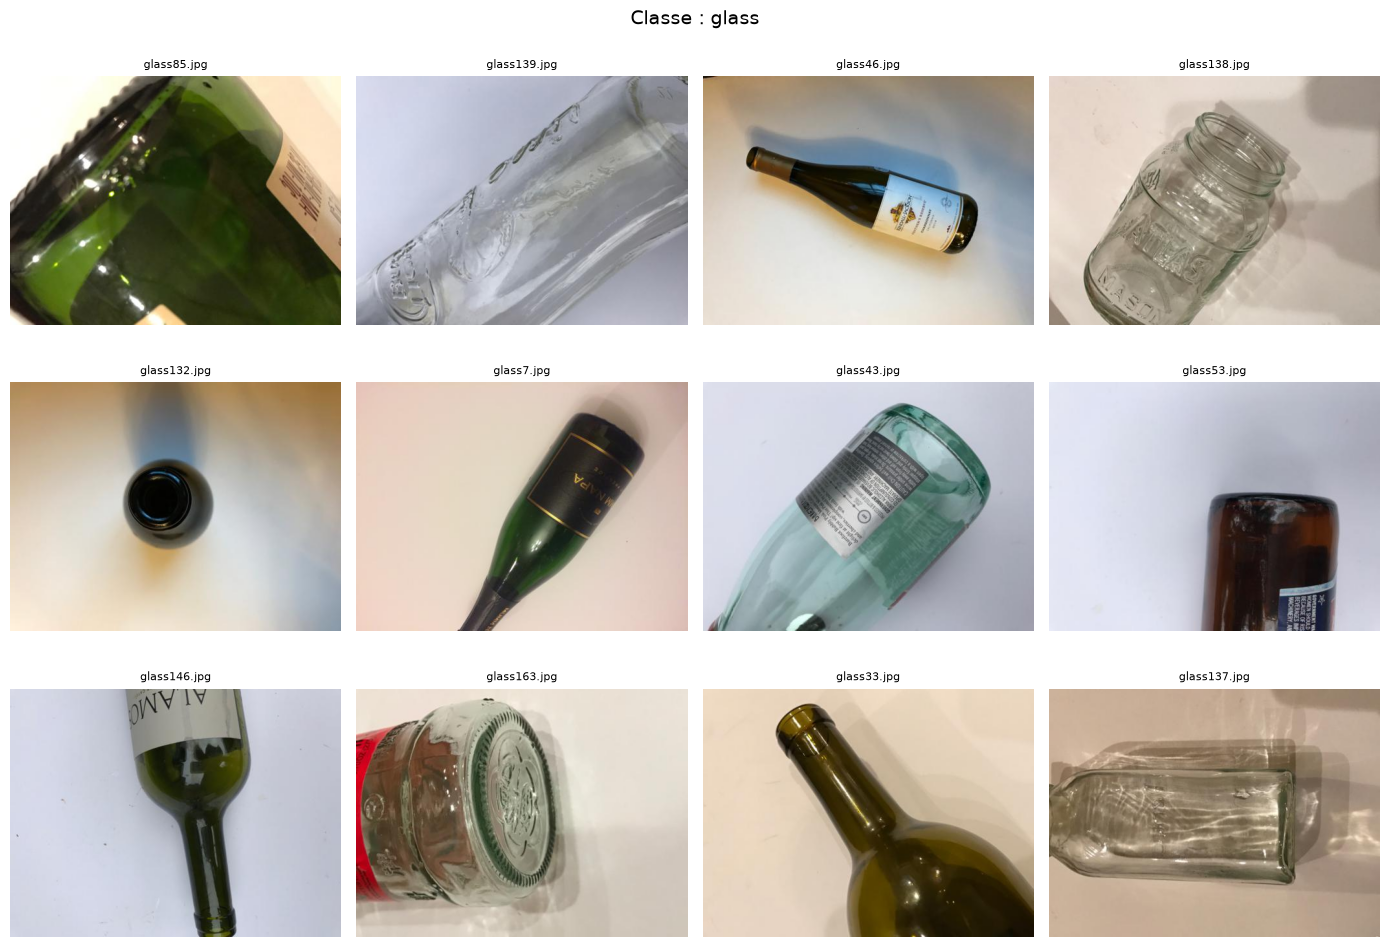

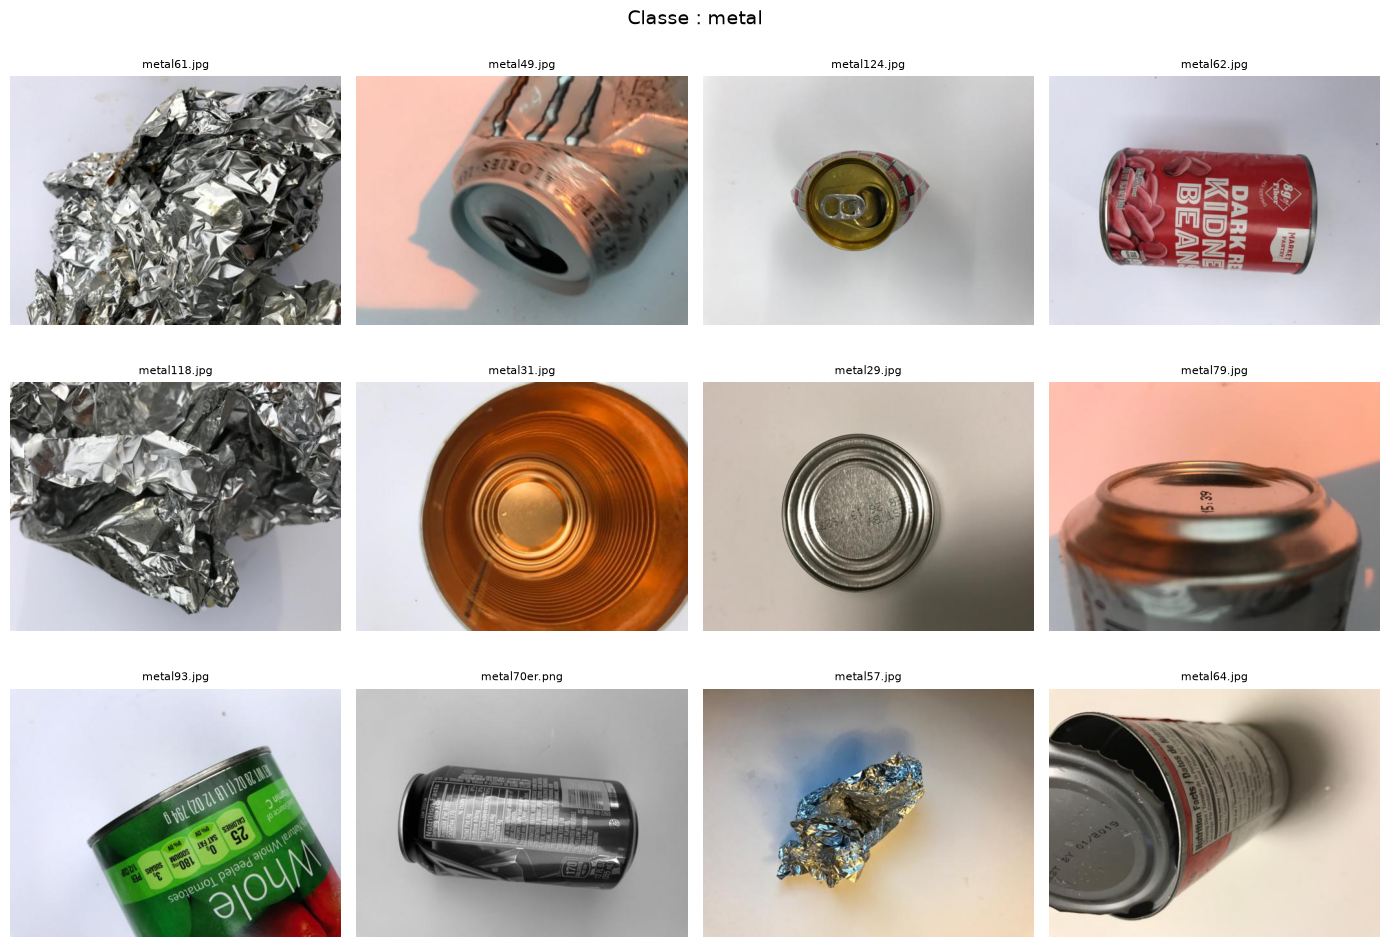

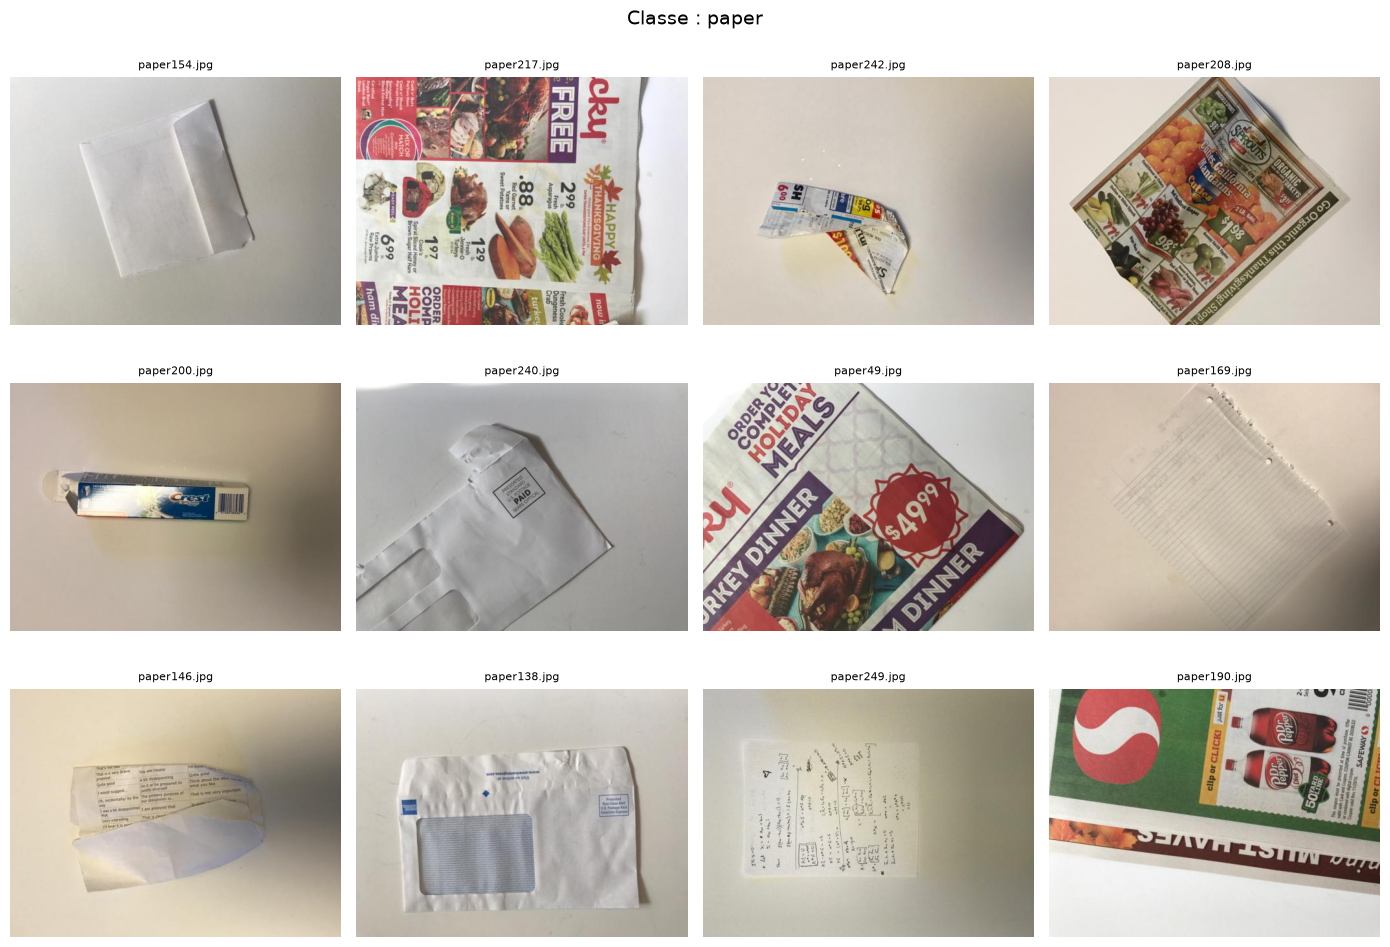

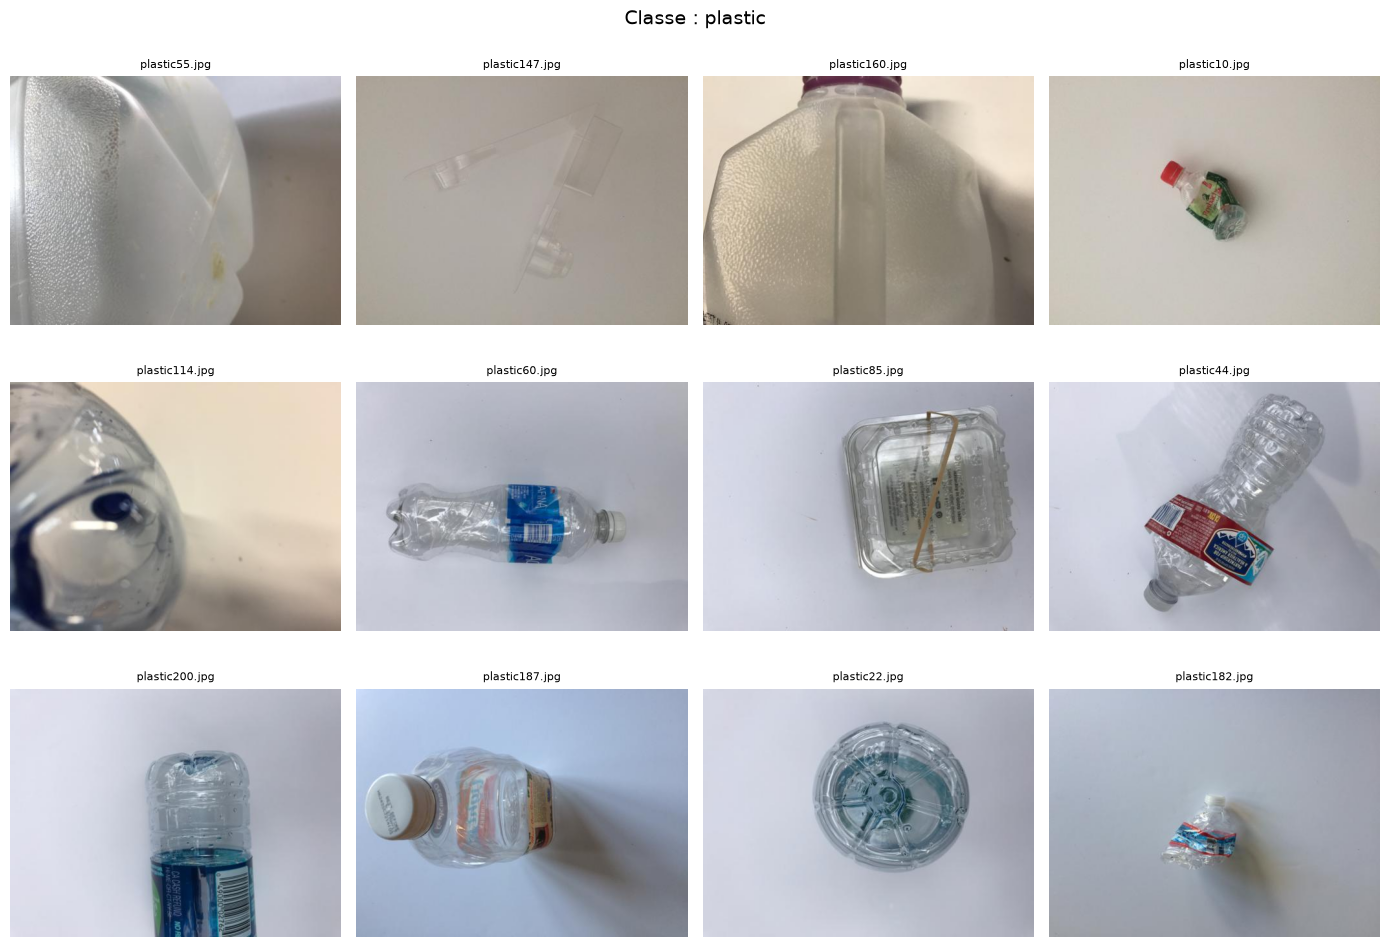

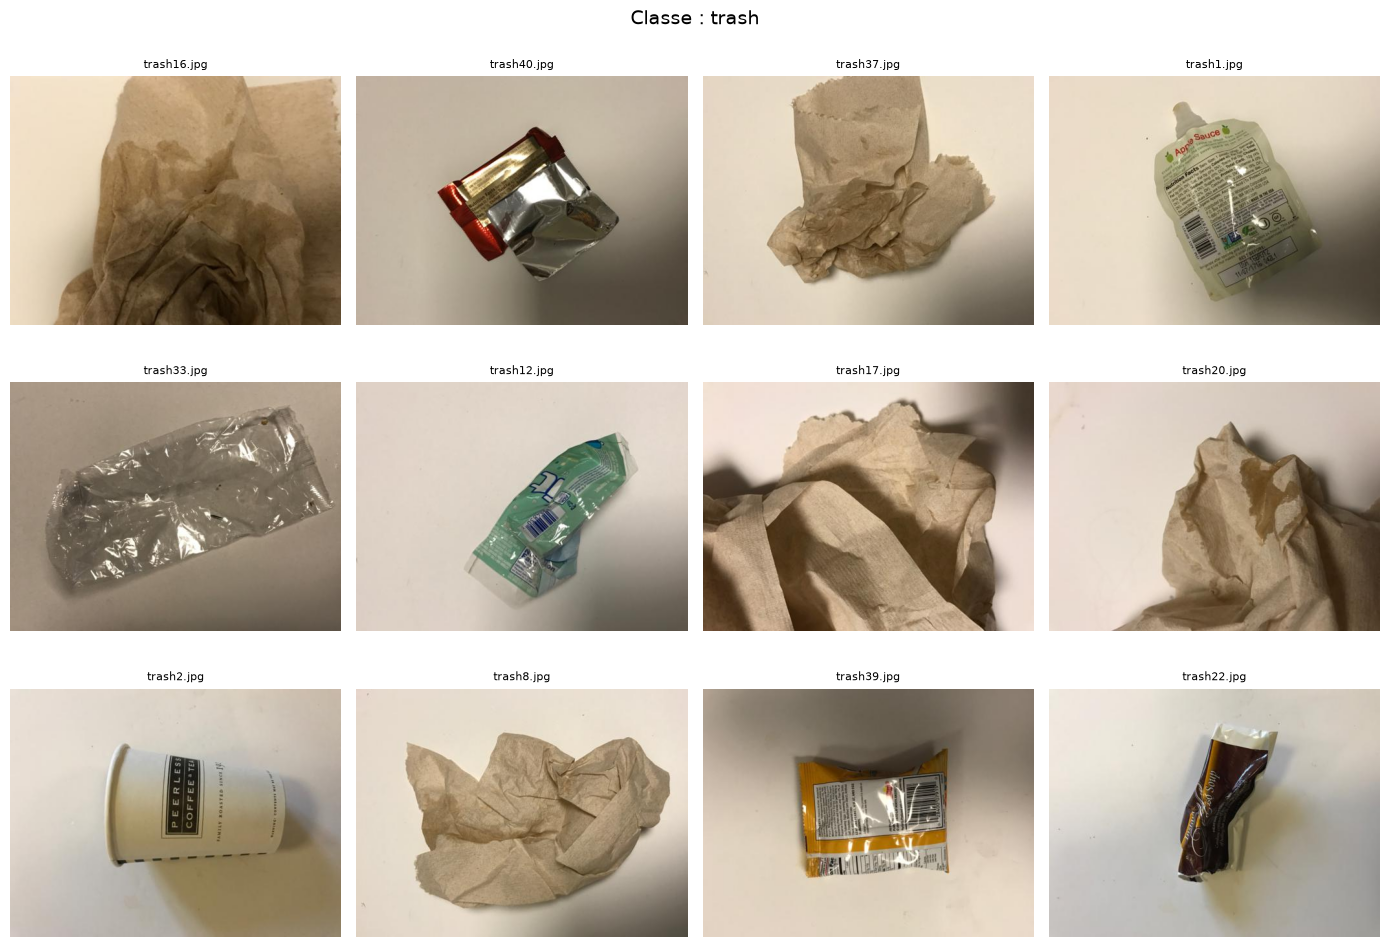

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

def afficher_echantillons(classe: str, n: int = 12):
    sous_df = df_valides[df_valides["classe"] == classe]
    sous_df = sous_df.sample(min(n, len(sous_df)))
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    fig.suptitle(f"Classe : {classe}", fontsize=14)
    for ax, (_, row) in zip(axes.flat, sous_df.iterrows()):
        try:
            img = Image.open(row["chemin"])
            ax.imshow(img)
            ax.set_title(row["nom"], fontsize=8)
        except Exception:
            pass
        ax.axis("off")
    plt.tight_layout()
    plt.show()

for classe in CLASSES:
    afficher_echantillons(classe)

# À compléter à la main après le contrôle visuel ci-dessus :
images_mal_classees = []  # ex : ["../data/raw/glass/img_0123.jpg"]
audit["images_mal_classees"] = len(images_mal_classees)


## Partie 8 : Analyser le déséquilibre des classes
Déterminer le nombre d'images par classe

Nombre d'images par classe :
classe
paper        251
plastic      223
glass        187
cardboard    168
metal        148
trash         49
Name: count, dtype: int64


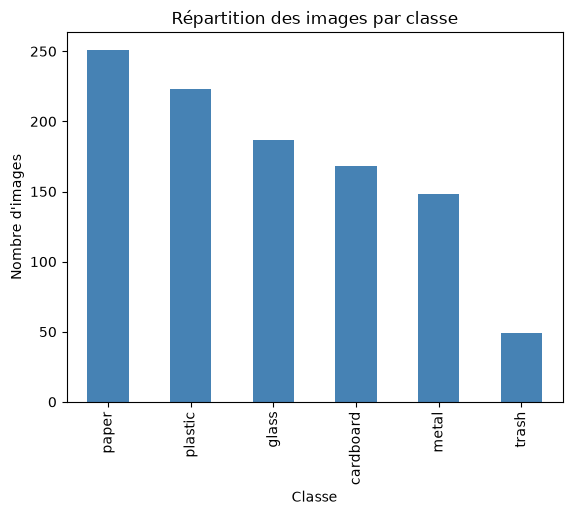


Classe minoritaire : trash (49 images)
Classe majoritaire : paper (251 images)


In [17]:
import matplotlib.pyplot as plt

compte_classes = df_valides["classe"].value_counts()
print("Nombre d\'images par classe :")
print(compte_classes)

compte_classes.plot(kind="bar", title="Répartition des images par classe", color="steelblue")
plt.xlabel("Classe")
plt.ylabel("Nombre d\'images")
plt.show()

classe_minoritaire = compte_classes.idxmin()
classe_majoritaire = compte_classes.idxmax()
print(f"\nClasse minoritaire : {classe_minoritaire} ({compte_classes.min()} images)")
print(f"Classe majoritaire : {classe_majoritaire} ({compte_classes.max()} images)")


## sélection des images propres

Avant de nettoyer/sauvegarder, on exclut les images corrompues, vides, trop petites, en doublon
ou mal classées identifiées dans les Parties 2, 3, 4, 6 et 7. `data/raw/` reste inchangé.

In [18]:
chemins_a_exclure = set(images_corrompues["chemin"]) \
    | set(images_vides["chemin"]) \
    | set(images_trop_petites["chemin"]) \
    | set(images_mal_classees)

chemins_doublons_a_retirer = set()
if not df_doublons.empty:
    for h, groupe in df_doublons.groupby("hash"):
        chemins_doublons_a_retirer.update(groupe["chemin"].tolist()[1:])  # garde le 1er, retire le reste
chemins_a_exclure |= chemins_doublons_a_retirer

df_propre = df_valides[~df_valides["chemin"].isin(chemins_a_exclure)].copy()
print(f"Images conservées pour le nettoyage : {len(df_propre)} sur {len(df)}")

for classe in CLASSES:
    (CLEANED_DIR / classe).mkdir(parents=True, exist_ok=True)

Images conservées pour le nettoyage : 996 sur 1032


## Partie 9 : Redimensionnement
Redimensionner toutes les images à 224 × 224.
NB : Redimensionnement avec conservation des proportions et ajout éventuel de padding

In [19]:
from PIL import Image, ImageOps

TAILLE_CIBLE = (224, 224)  

def redimensionner_avec_padding(img: Image.Image, taille_cible=(224, 224), couleur_padding=(0, 0, 0)) -> Image.Image:
    """Redimensionne en conservant le ratio, puis complète (padding) pour atteindre taille_cible."""
    img_ratio = ImageOps.contain(img, taille_cible)
    fond = Image.new("RGB", taille_cible, couleur_padding)
    x = (taille_cible[0] - img_ratio.width) // 2
    y = (taille_cible[1] - img_ratio.height) // 2
    fond.paste(img_ratio, (x, y))
    return fond


def redimensionner_et_sauvegarder(row) -> str:
    chemin_source = Path(row["chemin"])
    chemin_dest = CLEANED_DIR / row["classe"] / chemin_source.name
    with Image.open(chemin_source) as img:
        img_redim = redimensionner_avec_padding(img.convert("RGB"), TAILLE_CIBLE)
        img_redim.save(chemin_dest)
    return str(chemin_dest)



df_propre["chemin_cleaned"] = df_propre.apply(redimensionner_et_sauvegarder, axis=1)
print(f"{len(df_propre)} images redimensionnées et sauvegardées dans {CLEANED_DIR}")
df_propre[["nom", "classe", "chemin_cleaned"]].head()


996 images redimensionnées et sauvegardées dans ../data/cleaned


,nom,classe,chemin_cleaned
0,cardboard1.jpg,cardboard,../data/cleaned/cardboard/cardboard1.jpg
1,cardboard10.jpg,cardboard,../data/cleaned/cardboard/cardboard10.jpg
2,cardboard100.jpg,cardboard,../data/cleaned/cardboard/cardboard100.jpg
3,cardboard101.jpg,cardboard,../data/cleaned/cardboard/cardboard101.jpg
4,cardboard102.jpg,cardboard,../data/cleaned/cardboard/cardboard102.jpg


## Partie 10 : Uniformisation des canaux
Convertir toutes les images en RGB

In [20]:
from PIL import Image

def uniformiser_rgb(img: Image.Image) -> Image.Image:
    """Convertit n'importe quelle image (grayscale, RGBA, palette...) en RGB."""
    return img.convert("RGB")


# Vérification/uniformisation de sécurité sur les images déjà sauvegardées en Partie 9
for chemin in df_propre["chemin_cleaned"]:
    with Image.open(chemin) as img:
        if img.mode != "RGB":
            uniformiser_rgb(img).save(chemin)

modes_restants = {Image.open(c).mode for c in df_propre["chemin_cleaned"]}
print(f"Modes présents dans data/cleaned après uniformisation : {modes_restants}")


Modes présents dans data/cleaned après uniformisation : {'P', 'RGB'}


## Partie 11 : Mise à l'échelle des pixels
Normaliser les valeurs des pixels de toutes les images

In [21]:
import numpy as np
from PIL import Image


def normaliser_pixels(img: Image.Image) -> np.ndarray:
    """Renvoie un tableau RGB de pixels normalisés dans [0, 1]."""
    return np.asarray(img.convert("RGB"), dtype="float32") / 255.0


def normaliser_fichier(chemin: str) -> np.ndarray:
    with Image.open(chemin) as img:
        return normaliser_pixels(img)


# Construction du tableau X normalisé utilisé plus tard pour l'entraînement
X_normalise = np.stack([
    normaliser_fichier(chemin) for chemin in df_propre["chemin_cleaned"]
])
print(f"Tableau normalisé : shape={X_normalise.shape}, min={X_normalise.min()}, max={X_normalise.max()}")


Tableau normalisé : shape=(996, 224, 224, 3), min=0.0, max=1.0


## Partie 12 : Découpage Train/Validation/Test
Découper le dataset nettoyé (cleaned) en trois sous-ensembles : train, validation et test

In [22]:
import shutil
from sklearn.model_selection import train_test_split

RATIO_TRAIN, RATIO_VAL, RATIO_TEST = 0.7, 0.15, 0.15

df_train, df_temp = train_test_split(
    df_propre, test_size=(RATIO_VAL + RATIO_TEST), stratify=df_propre["classe"], random_state=42
)
df_val, df_test = train_test_split(
    df_temp, test_size=RATIO_TEST / (RATIO_VAL + RATIO_TEST), stratify=df_temp["classe"], random_state=42
)

print(f"Train : {len(df_train)}  |  Validation : {len(df_val)}  |  Test : {len(df_test)}")

for split_name, split_df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    for classe in CLASSES:
        (CLEANED_DIR.parent / split_name / classe).mkdir(parents=True, exist_ok=True)
    for _, row in split_df.iterrows():
        src = Path(row["chemin_cleaned"])
        dst = CLEANED_DIR.parent / split_name / row["classe"] / src.name
        shutil.copy2(src, dst)

print("Découpage effectué : data/train, data/val, data/test")


Train : 697  |  Validation : 149  |  Test : 150
Découpage effectué : data/train, data/val, data/test


## Partie 13 : Data Augmentation
### 1) A l’aide de Keras, appliquer à la classe minoritaire de la « data augmentation » en utilisant des transformations comme rotation légère, retournement horizontal, zoom, translation, variation de luminosité, variation de contraste, légère variation de couleur, …

In [ ]:
from pathlib import Path
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img

datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=(0.8, 1.2),
    channel_shift_range=20,
)

def augmenter_classe_minoritaire(classe: str, dossier_train: Path, n_images_cible: int):
    dossier_classe = dossier_train / classe
    images_existantes = list(dossier_classe.glob("*"))
    n_a_generer = max(0, n_images_cible - len(images_existantes))
    print(f"{classe} : {len(images_existantes)} images -> génération de {n_a_generer} images augmentées")

    i = 0
    while i < n_a_generer:
        chemin_source = images_existantes[i % len(images_existantes)]
        img = Image.open(chemin_source).convert("RGB")
        arr = img_to_array(img).reshape((1,) + img_to_array(img).shape)

        for batch in datagen.flow(arr, batch_size=1):
            array_to_img(batch[0]).save(dossier_classe / f"aug_{i}_{chemin_source.name}")
            i += 1
            break


compte_train = df_train["classe"].value_counts()
taille_cible_classe = int(compte_train.max())  # on équilibre sur la classe la plus représentée dans train

for classe in CLASSES:
    augmenter_classe_minoritaire(classe, CLEANED_DIR.parent / "train", taille_cible_classe)


cardboard : 171 images -> génération de 0 images augmentées
glass : 171 images -> génération de 0 images augmentées
metal : 171 images -> génération de 0 images augmentées
paper : 171 images -> génération de 0 images augmentées
plastic : 171 images -> génération de 0 images augmentées
trash : 171 images -> génération de 0 images augmentées
